# LIRARIES 


In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

!pip install xgboost

from xgboost import XGBClassifier


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# LOADDATA

In [3]:
df = pd.read_csv("Country-data.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


#PREPOCEESING

In [4]:
country_names = df["country"]

df = df.drop("country", axis=1)

# Handle missing values
df.fillna(df.mean(), inplace=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [5]:
df["GDP_Category"] = pd.qcut(
    df["gdpp"],
    q=3,
    labels=["Low", "Medium", "High"]
)

label_encoder = LabelEncoder()
df["GDP_Category"] = label_encoder.fit_transform(df["GDP_Category"])

In [6]:
X = df.drop("GDP_Category", axis=1)
y = df["GDP_Category"]

# FEATURE SCALING

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# RANDOMFOREST MODEL

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy:
0.9117647058823529

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.73      0.84        11
           2       0.79      1.00      0.88        11

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.91        34
weighted avg       0.93      0.91      0.91        34



# XG BOOST MODEL

In [24]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("\nXGBoost Accuracy:")
print(accuracy_score(y_test, xgb_pred))


XGBoost Accuracy:
1.0


# FEATURE IMPORTNACE


Top Features:
      Feature  Importance
8        gdpp    0.440213
4      income    0.254410
0  child_mort    0.125822
6  life_expec    0.073755
7   total_fer    0.045601
5   inflation    0.020914
1     exports    0.018119
2      health    0.010598
3     imports    0.010568


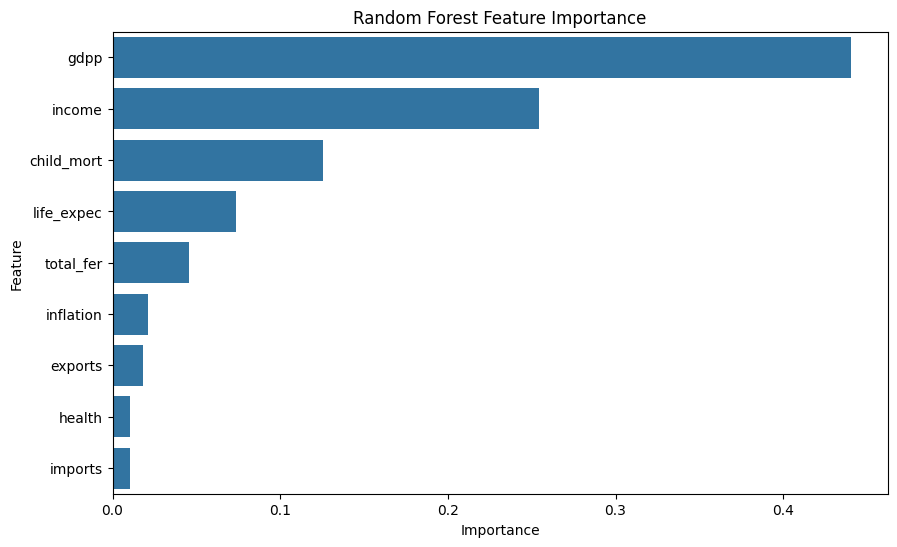

In [13]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Features:")
print(importance_df.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.show()

# K MEANS CLUSTRING

In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("\nKMeans Silhouette Score:")
print(silhouette_score(X_scaled, kmeans_labels))


KMeans Silhouette Score:
0.29595170577528157


# DB SCAN

In [15]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print("\nDBSCAN Clusters:")
print(np.unique(dbscan_labels))


DBSCAN Clusters:
[-1  0]


# PCA VISUALIZATION

In [25]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

#  KMEANS VISUALIZATION

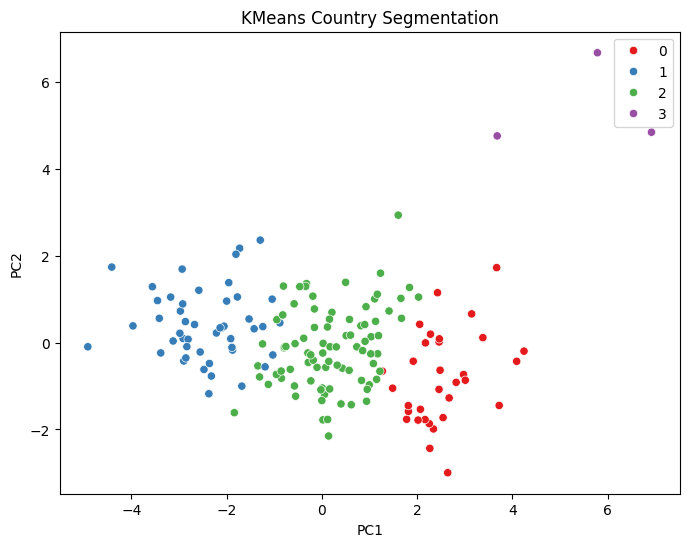

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=kmeans_labels,
    palette="Set1"
)

plt.title("KMeans Country Segmentation")
plt.show()

# DBSCAN VISUALIZATION

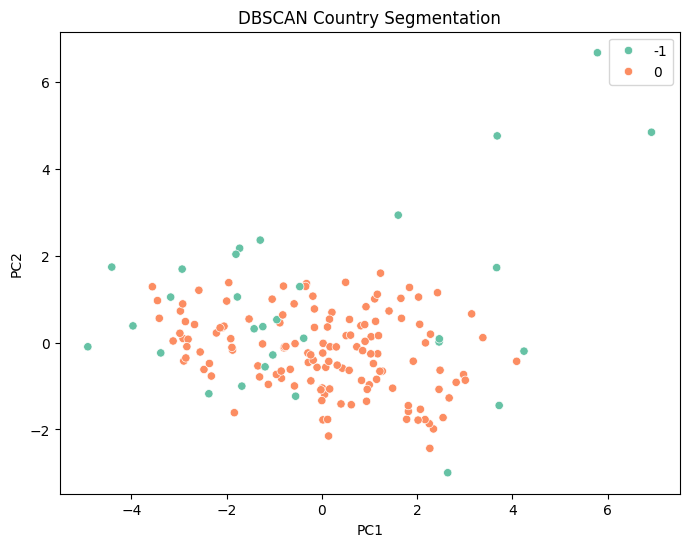

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=dbscan_labels,
    palette="Set2"
)

plt.title("DBSCAN Country Segmentation")
plt.show()

# CLUSTER INSIGHTS

In [21]:
cluster_summary = df.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

print("\nCluster Summary:")
print(cluster_summary)



Cluster Summary:
                child_mort     exports    health     imports        income  \
KMeans_Cluster                                                               
0                 5.181250   46.118750  9.088437   40.584375  44021.875000   
1                92.961702   29.151277  6.388511   42.323404   3942.404255   
2                21.690588   41.073988  6.197059   47.914893  12671.411765   
3                 4.133333  176.000000  6.793333  156.666667  64033.333333   

                inflation  life_expec  total_fer          gdpp  GDP_Category  \
KMeans_Cluster                                                                 
0                2.513844   80.081250   1.788437  42118.750000      0.000000   
1               12.019681   59.187234   5.008085   1922.382979      1.127660   
2                7.609341   72.871765   2.300706   6519.552941      1.329412   
3                2.468000   81.433333   1.380000  57566.666667      0.000000   

                DBSCAN_Cluster  

# differnce of training and testing of Random forest model

In [28]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9117647058823529
